# MPRAlm barcode variation

In [6]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr
import os
pl.Config.set_fmt_str_lengths(50)

polars.config.Config

In [8]:
input_dir = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results"
sample_name = "all_NGN2"
mpralm = pl.read_ipc(os.path.join(input_dir, f"bc_MPRAlm/toptable_{sample_name}.feather"), memory_map=False)

mpralm_bc = pl.read_ipc(os.path.join(input_dir, f"MPRAlm/toptable_{sample_name}.feather"), memory_map=False)
both = mpralm.join(mpralm_bc, on="variant_id")

In [9]:
both = both.select( 
    pl.all().map_alias(lambda col_name: col_name.replace('right', 'bc'))
)

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-92/ipykernel_787107/3910053613.py:2: DeprecationWarning: `map_alias` is deprecated. It has been moved to `name.map`.
  pl.all().map_alias(lambda col_name: col_name.replace('right', 'bc'))


In [10]:
# just a check how many sequences have a very small logFC when using bc MPRAlm and a higher logFC with normal MPRAlm
both.filter(((pl.col("logFC_bc") < 0.05) & (pl.col("logFC_bc") > - 0.05)) & (pl.col("logFC") > 0.5)).height

0

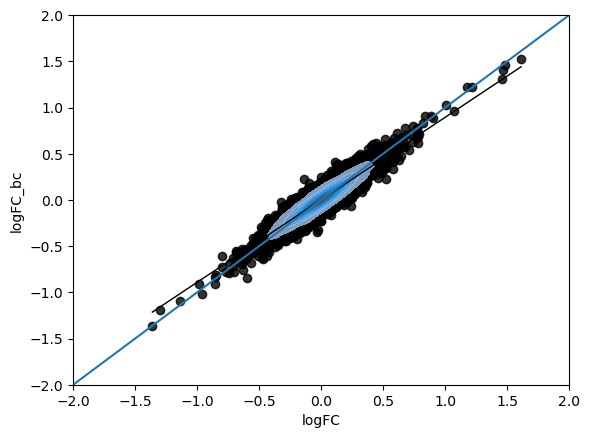

In [11]:
fig, ax = plt.subplots()
ax.set_xlim([-2,2])
ax.set_ylim([-2,2])
sns.regplot(both, x="logFC", y="logFC_bc", color="k", ax=ax, line_kws={"linewidth":1})
sns.kdeplot(both, x="logFC", y="logFC_bc", fill=True, alpha=0.8, ax=ax)
plt.plot
plt.plot(range(-2,3), range(-2,3))

In [12]:
# calculate correlation
both.select(pl.corr("logFC_bc", "logFC"))

logFC_bc
f64
0.930243


### Preprocess

In [25]:
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt

name = "standard"
name = "lowConfig"
input = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/%s_NGN2_filtered_counts_sequences.tsv.gz"%(name)
output_rna = "/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/preprocess/%s_mpralm_bc_rna_input_NGN2.tsv"%(name)
output_dna = "/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/preprocess/%s_mpralm_bc_dna_input_NGN2.tsv"%(name)
output_both = "/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/preprocess/%s_mpralm_input_NGN2.tsv"%(name)


In [12]:
print("Reading data... ", input)
df = pl.read_csv(input, separator="\t")
print("Number of variants with ref and alt after MPRAsnakeflow: ", df.n_unique("variant_id"))

Reading data...  /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_filtered_counts_sequences.tsv.gz
Number of variants with ref and alt after MPRAsnakeflow:  42598


#### optional filtering

In [7]:
# filter for barcodes with a DNA count of at least 2 (filter space down)
#df = df.filter(pl.all_horizontal(pl.col("^DNA.*$") > 0))
#df = df.filter(pl.all_horizontal(pl.col("^RNA.*$") > 0))
print("Number of variants after optional filtering on DNA or RNA counts: ", df.n_unique("variant_id"))

Number of variants after optional filtering on DNA or RNA counts:  42598


#### Filter sequences with at least 2 barcodes in both alleles

In [11]:
# filter for oligos with at least 2 barcodes in both alleles
df = df.filter(pl.count().over(["variant_id", "allele"]) >= 2)
df = df.filter(pl.n_unique("allele").over("variant_id") == 2)
print("Number of variants after filtering for number of barcodes: ", df.n_unique("variant_id"))

/tmp/ipykernel_208010/1106599813.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  df = df.filter(pl.count().over(["variant_id", "allele"]) >= 2)


Number of variants after filtering for number of barcodes:  42137


In [22]:
# show list of variant_id 
pl.Config.set_fmt_str_lengths(100)
df

variant_id,allele,barcode,DNA1,RNA1,DNA2,RNA2,DNA3,RNA3
str,str,str,i64,i64,i64,i64,i64,i64
"""cardiac_neuro_cava_random:AARS1|ENSG00000090861.17|EH38E1825123|16-70223377-C-G""","""alt""","""AAAACAAGCATACGG""",4,13,3,4,5,7
"""cardiac_neuro_cava_random:AARS1|ENSG00000090861.17|EH38E1825123|16-70223377-C-G""","""alt""","""AACGCTGACCGGGAC""",1,4,0,4,0,8
"""cardiac_neuro_cava_random:AARS1|ENSG00000090861.17|EH38E1825123|16-70223377-C-G""","""alt""","""AAGTTGATCCCATTC""",2,8,2,9,3,3
"""cardiac_neuro_cava_random:AARS1|ENSG00000090861.17|EH38E1825123|16-70223377-C-G""","""alt""","""AATCCGTCCAAGTCG""",9,14,7,18,12,16
"""cardiac_neuro_cava_random:AARS1|ENSG00000090861.17|EH38E1825123|16-70223377-C-G""","""alt""","""AATGACAACTCACTT""",15,28,10,21,9,29
…,…,…,…,…,…,…,…,…
"""cardiac_neuro_cava_random:ZNF462|ENSG00000148143.13|EH38E3899619|9-107051216-T-C""","""ref""","""TTGCAGCGAGGAACC""",6,9,6,14,5,8
"""cardiac_neuro_cava_random:ZNF462|ENSG00000148143.13|EH38E3899619|9-107051216-T-C""","""ref""","""TTGGCAGCCCGTCGC""",6,4,3,7,1,8
"""cardiac_neuro_cava_random:ZNF462|ENSG00000148143.13|EH38E3899619|9-107051216-T-C""","""ref""","""TTGGGCTCCGAGTAG""",10,9,4,8,6,9


#### Plot barcodes per sequence of the variants

/tmp/ipykernel_208010/3755901930.py:2: DeprecationWarning: `count` is deprecated. It has been renamed to `len`.
  bc_number_tbl = df.group_by(["variant_id"]).count()


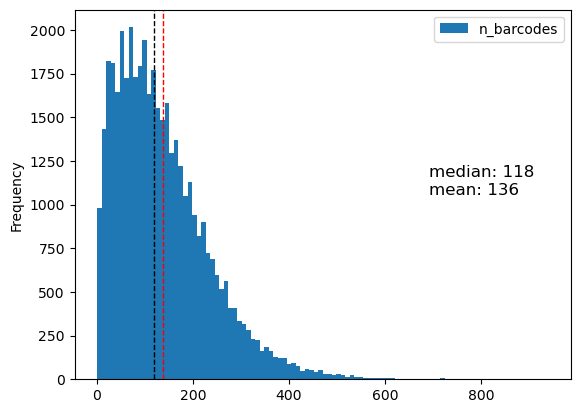

In [52]:
# show number of barcodes per variant in a histogram and annotate the median and mean number of barcodes
bc_number_tbl = df.group_by(["variant_id"]).count()
bc_number_tbl = bc_number_tbl.select(pl.col("count").alias("n_barcodes"))
bc_number_tbl = bc_number_tbl.sort("n_barcodes")
bc_number_tbl = bc_number_tbl.select(pl.col("n_barcodes"))
bc_number_tbl = bc_number_tbl.to_pandas()
bc_number_tbl.plot.hist(bins=100)
# annotate the mean and median value as text in the right upper corner below the legend

plt.axvline(bc_number_tbl.median().values[0], color='k', linestyle='dashed', linewidth=1)
plt.axvline(bc_number_tbl.mean().values[0], color='r', linestyle='dashed', linewidth=1)
# get mean frequency of barcodes per variant
ylim = plt.gca().get_ylim()
xlim = plt.gca().get_xlim()

# add text to the plot (half y-axis, 0.8 x-axis)
plt.text(xlim[1]*0.7, ylim[1]*0.5, "median: %d\nmean: %d"%(bc_number_tbl.median().values[0], bc_number_tbl.mean().values[0]), fontsize=12)

plt.show()

#### Filter based on the number of barcodes

In [ ]:
# the max number of barcodes used per oligo is the number of barcodes of the 0.95th quantile of the sequences.
max_bc = df.group_by(["variant_id", "allele"]).count().select("count").quantile(0.95).item()

# downsample barcodes
df = df.filter(pl.int_range(0, pl.count()).shuffle().over(["variant_id", "allele"]) < max_bc)


#### Pivot tables

In [ ]:
# pivot dataframes so that each BC is a new column
df = df.with_columns(pl.int_range(1, pl.col("barcode").count()+1).over(["variant_id", "allele"]).alias("bc"))
df = df.with_columns(new_idx = pl.col("bc").cast(pl.Utf8) + "_" + pl.col("allele"))
df_rna = df.pivot(values=cs.contains("RNA"), index="variant_id", columns="new_idx", sort_columns=True)
df_dna = df.pivot(values=cs.contains("DNA"), index="variant_id", columns="new_idx", sort_columns=True)
df_rna = df_rna.select(
    pl.all().name.map(lambda col_name: col_name.replace('RNA', 'sample').replace('new_idx_', 'bc'))
).sort("variant_id")
df_dna = df_dna.select(
    pl.all().name.map(lambda col_name: col_name.replace('DNA', 'sample').replace('new_idx_', 'bc'))
).sort("variant_id")

#### Write output

In [ ]:
# # input for normal mpralm
# df.write_csv(output_both, separator="\t")

# df_rna.write_csv(output_rna, separator="\t")
# df_dna.write_csv(output_dna, separator="\t")